# Day 46/100 - Relevance Vector Machine (RVM)
**Dataset:** Pima Indians Diabetes  
**Objectif:** Classification binaire avec RVM et prédictions probabilistes calibrées

In [25]:
#%pip install sklearn-rvm


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.calibration import calibration_curve
from sklearn_rvm import EMRVC

np.random.seed(42)

In [13]:
# Chargement du dataset Pima Indians Diabetes
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 
           'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
data = pd.read_csv(url, names=columns)

# Séparation features/target
X = data.drop('Outcome', axis=1).values
y = data['Outcome'].values

# Split train/test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dataset shape: {X.shape}")
print(f"Train set: {X_train.shape[0]} exemples")
print(f"Test set: {X_test.shape[0]} exemples")
print(f"Proportion diabète: {y.mean():.2%}")

Dataset shape: (768, 8)
Train set: 614 exemples
Test set: 154 exemples
Proportion diabète: 34.90%


In [14]:
# Sélection d'hyperparamètre via 5-Fold Cross-Validation (plus rapide)
candidate_gammas = [0.01, 0.1, 0.5]  # Espace réduit pour accélérer
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gamma_cv_scores = {}

for gamma in candidate_gammas:
    fold_scores = []
    
    for train_idx, val_idx in skf.split(X_train, y_train):
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
        
        # Standardisation par fold (pas de fuite de données)
        scaler_fold = StandardScaler()
        X_fold_train_scaled = scaler_fold.fit_transform(X_fold_train)
        X_fold_val_scaled = scaler_fold.transform(X_fold_val)
        
        # Entraîner et évaluer
        model = EMRVC(kernel='rbf', gamma=gamma)
        model.fit(X_fold_train_scaled, y_fold_train)
        y_fold_pred = model.predict(X_fold_val_scaled)
        fold_f1 = f1_score(y_fold_val, y_fold_pred)
        fold_scores.append(fold_f1)
    
    gamma_cv_scores[gamma] = np.mean(fold_scores)

# Meilleur gamma
best_gamma = max(gamma_cv_scores, key=gamma_cv_scores.get)
best_cv_f1 = gamma_cv_scores[best_gamma]

# Entraînement final sur tout le train avec le meilleur gamma
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train)
X_test_scaled = scaler_final.transform(X_test)

rvm_rbf = EMRVC(kernel='rbf', gamma=best_gamma)
rvm_rbf.fit(X_train_scaled, y_train)

# Prédictions test
y_pred = rvm_rbf.predict(X_test_scaled)
y_proba = rvm_rbf.predict_proba(X_test_scaled)[:, 1]
n_vectors = len(rvm_rbf.relevance_)

results = {
    'RVM RBF': {
        'y_pred': y_pred,
        'y_proba': y_proba,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'n_vectors': n_vectors,
        'best_gamma': best_gamma,
        'best_cv_f1': best_cv_f1
    }
}

In [15]:
# Affichage des résultats RVM
res = results['RVM RBF']

print("RÉSULTATS RVM - Pima Indians Diabetes")
print("Sélection hyperparamètre: 5-Fold Cross-Validation")
print(f"  Meilleur gamma: {res['best_gamma']}")
print(f"  F1 CV (moyenne): {res['best_cv_f1']:.4f}")
print(f"  Gammas testés: {list(gamma_cv_scores.keys())} -> {[f'{v:.4f}' for v in gamma_cv_scores.values()]}")

print("\nÉvaluation finale: test set")
print(f"  Accuracy:  {res['accuracy']:.4f}")
print(f"  Precision: {res['precision']:.4f}")
print(f"  Recall:    {res['recall']:.4f}")
print(f"  F1-Score:  {res['f1']:.4f}")
print(f"  Vecteurs:  {res['n_vectors']}/{len(X_train_scaled)} ({res['n_vectors']/len(X_train_scaled):.1%})")

RÉSULTATS RVM - Pima Indians Diabetes
Sélection hyperparamètre: 5-Fold Cross-Validation
  Meilleur gamma: 0.01
  F1 CV (moyenne): 0.6631
  Gammas testés: [0.01, 0.1, 0.5] -> ['0.6631', '0.6581', '0.5965']

Évaluation finale: test set
  Accuracy:  0.7338
  Precision: 0.6444
  Recall:    0.5370
  F1-Score:  0.5859
  Vecteurs:  6/614 (1.0%)


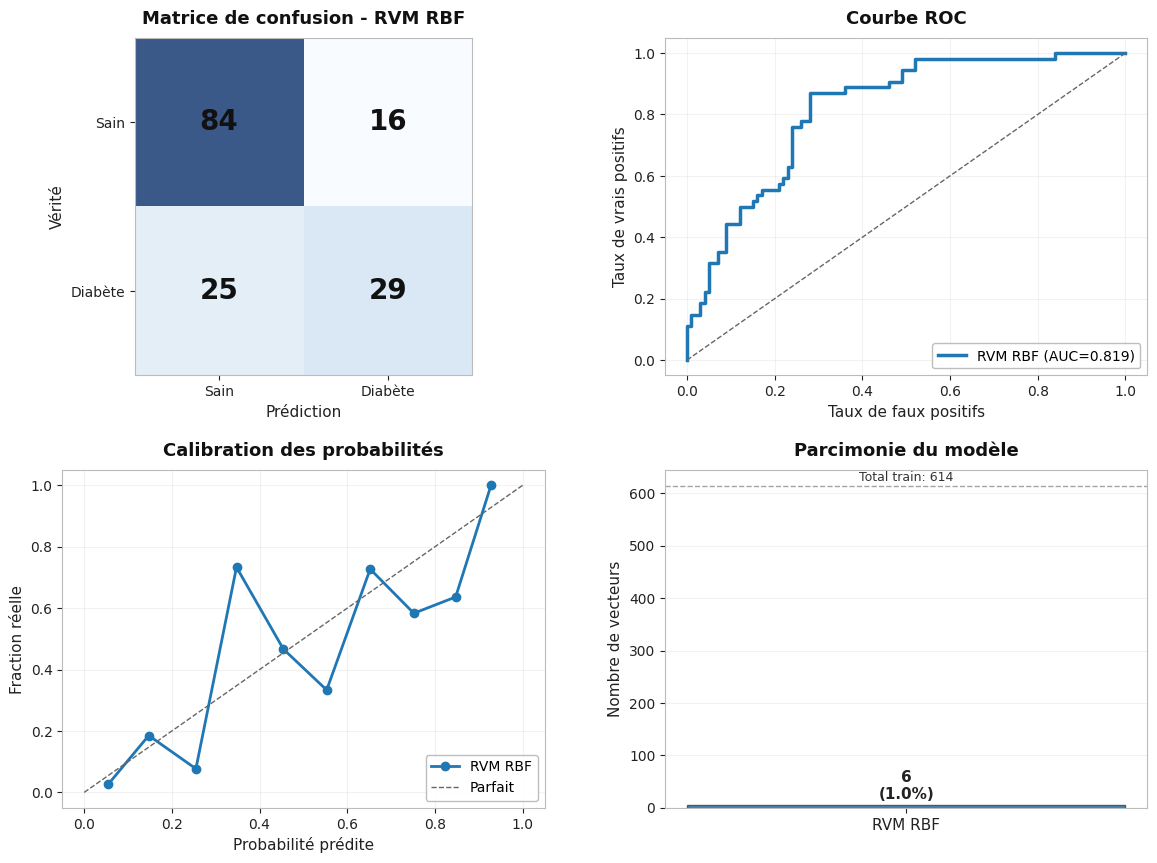

In [16]:
# Visualisation RVM uniquement (fond blanc)
res = results['RVM RBF']

fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.28, wspace=0.25)

# 1. Matrice de confusion
ax_cm = fig.add_subplot(gs[0, 0])
ax_cm.set_facecolor('white')
cm = confusion_matrix(y_test, res['y_pred'])
ax_cm.imshow(cm, cmap='Blues', alpha=0.8)

for i in range(2):
    for j in range(2):
        ax_cm.text(
            j, i, str(cm[i, j]),
            ha='center', va='center', color='#111111', fontsize=20, weight='bold'
        )

ax_cm.set_xticks([0, 1])
ax_cm.set_yticks([0, 1])
ax_cm.set_xticklabels(['Sain', 'Diabète'], color='#222222')
ax_cm.set_yticklabels(['Sain', 'Diabète'], color='#222222')
ax_cm.set_xlabel('Prédiction', color='#222222', fontsize=11)
ax_cm.set_ylabel('Vérité', color='#222222', fontsize=11)
ax_cm.set_title('Matrice de confusion - RVM RBF', color='#111111', fontsize=13, weight='bold', pad=10)
ax_cm.tick_params(colors='#222222')
for spine in ax_cm.spines.values():
    spine.set_color('#BBBBBB')

# 2. Courbe ROC
ax_roc = fig.add_subplot(gs[0, 1])
ax_roc.set_facecolor('white')
fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
roc_auc = auc(fpr, tpr)
ax_roc.plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'RVM RBF (AUC={roc_auc:.3f})')
ax_roc.plot([0, 1], [0, 1], '--', color='#666666', lw=1)
ax_roc.set_xlabel('Taux de faux positifs', color='#222222', fontsize=11)
ax_roc.set_ylabel('Taux de vrais positifs', color='#222222', fontsize=11)
ax_roc.set_title('Courbe ROC', color='#111111', fontsize=13, weight='bold', pad=10)
ax_roc.tick_params(colors='#222222')
ax_roc.grid(True, alpha=0.25, color='#CCCCCC')
for spine in ax_roc.spines.values():
    spine.set_color('#BBBBBB')
legend = ax_roc.legend(loc='lower right', fontsize=10, framealpha=0.95)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('#BBBBBB')

# 3. Calibration
ax_cal = fig.add_subplot(gs[1, 0])
ax_cal.set_facecolor('white')
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test, res['y_proba'], n_bins=10, strategy='uniform'
 )
ax_cal.plot(
    mean_predicted_value, fraction_of_positives, 'o-',
    color='#1f77b4', lw=2, markersize=6, label='RVM RBF'
 )
ax_cal.plot([0, 1], [0, 1], '--', color='#666666', lw=1, label='Parfait')
ax_cal.set_xlabel('Probabilité prédite', color='#222222', fontsize=11)
ax_cal.set_ylabel('Fraction réelle', color='#222222', fontsize=11)
ax_cal.set_title('Calibration des probabilités', color='#111111', fontsize=13, weight='bold', pad=10)
ax_cal.tick_params(colors='#222222')
ax_cal.grid(True, alpha=0.25, color='#CCCCCC')
for spine in ax_cal.spines.values():
    spine.set_color('#BBBBBB')
legend = ax_cal.legend(loc='lower right', fontsize=10, framealpha=0.95)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('#BBBBBB')

# 4. Parcimonie RVM
ax_sparse = fig.add_subplot(gs[1, 1])
ax_sparse.set_facecolor('white')
bars = ax_sparse.bar([0], [res['n_vectors']], color='#1f77b4', alpha=0.85, edgecolor='#444444', width=0.5)
for bar in bars:
    h = bar.get_height()
    ax_sparse.text(
        bar.get_x() + bar.get_width()/2., h + 5,
        f"{int(h)}\n({h/len(X_train_scaled):.1%})",
        ha='center', va='bottom', color='#222222', fontsize=11, weight='bold'
    )
ax_sparse.axhline(len(X_train_scaled), color='#666666', linestyle='--', alpha=0.6, lw=1)
ax_sparse.text(0, len(X_train_scaled) + 10, f"Total train: {len(X_train_scaled)}", color='#333333', fontsize=9, ha='center')
ax_sparse.set_xticks([0])
ax_sparse.set_xticklabels(['RVM RBF'], color='#222222', fontsize=11)
ax_sparse.set_ylabel('Nombre de vecteurs', color='#222222', fontsize=11)
ax_sparse.set_title('Parcimonie du modèle', color='#111111', fontsize=13, weight='bold', pad=10)
ax_sparse.tick_params(colors='#222222')
ax_sparse.grid(True, alpha=0.25, color='#CCCCCC', axis='y')
for spine in ax_sparse.spines.values():
    spine.set_color('#BBBBBB')
plt.show()